# Chapter 06: Tests of Uniformity and Goodness-of-Fit

Source span: printed pages 93-118; PDF pages 110-135.

The source chapter treats uniformity as the central circular null model, then builds tests that respect the fact that a circular origin is arbitrary. This notebook asks a standalone question: **when circular data look nonuniform, which geometry of nonuniformity is visible, and which test statistic is allowed to notice it?**

The goal is to turn each test into an inspectable object: a mean vector for Rayleigh, an origin-invariant empirical CDF discrepancy for Kuiper and Watson, gap and semicircle scans for spacing tests, and a probability integral transform for goodness-of-fit. All examples below are synthetic and reproducible; they are designed to expose the chapter ideas without copying printed examples, tables, or figures.


## Translation Guide

- A circular observation is represented by a unit complex number `exp(1j * theta)` or by the point `(cos theta, sin theta)` on the unit circle.
- Uniformity means no preferred origin or direction. Equivalently, every nonzero Fourier harmonic has zero population resultant.
- The Rayleigh test looks only at the first harmonic. It is powerful for a single preferred direction, but it can miss antipodal or multimodal structure.
- A circular empirical CDF depends on where the angle zero is placed. Kuiper adds the largest positive and negative discrepancies; Watson subtracts the mean discrepancy. Those operations remove the arbitrary origin from the statistic.
- Spacing and semicircle tests look at the geometry of gaps, clusters, and whether a half-circle contains too many or too few observations.
- A goodness-of-fit test for a continuous circular model uses the probability integral transform (PIT): map `theta` to `2*pi*F(theta)`, then test those transformed angles for uniformity.
- Simulation is used here as a calibration check and a failure-mode detector, not as a replacement for the analytic null theory in the source chapter.


In [1]:
from pathlib import Path
import sys


def find_book_root(start: Path) -> Path:
    for candidate in [start.resolve(), *start.resolve().parents]:
        if (candidate / "AGENTS.md").exists() and (candidate / "Directional Statistics.pdf").exists():
            return candidate
        nested = candidate / "Directional-Statistics"
        if (nested / "AGENTS.md").exists() and (nested / "Directional Statistics.pdf").exists():
            return nested
    raise RuntimeError("Could not locate the Directional-Statistics course root.")


BOOK_ROOT = find_book_root(Path.cwd())
if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

from utils.artifacts import display_artifact, save_json, save_matplotlib, save_plotly_html

TOPIC = "chapter-06"
ARTIFACT_ROOT = BOOK_ROOT / "artifacts" / TOPIC
ARTIFACT_ROOT.mkdir(parents=True, exist_ok=True)

print(f"BOOK_ROOT = {BOOK_ROOT}")
print(f"ARTIFACT_ROOT = {ARTIFACT_ROOT}")


BOOK_ROOT = D:\Geometry\Directional-Statistics
ARTIFACT_ROOT = D:\Geometry\Directional-Statistics\artifacts\chapter-06


In [2]:
from collections import OrderedDict

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Arc
from plotly.subplots import make_subplots
import plotly.graph_objects as go
from scipy.stats import chi2, vonmises

plt.rcParams.update({
    "figure.dpi": 130,
    "savefig.dpi": 170,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 10,
})
plt.ioff()

TAU = 2 * np.pi
rng = np.random.default_rng(202606)


def wrap(theta):
    return np.mod(np.asarray(theta, dtype=float), TAU)


def rel(path):
    return Path(path).resolve().relative_to(BOOK_ROOT.resolve()).as_posix()


def native(value):
    if isinstance(value, dict):
        return {str(k): native(v) for k, v in value.items()}
    if isinstance(value, (list, tuple)):
        return [native(v) for v in value]
    if isinstance(value, np.ndarray):
        return native(value.tolist())
    if isinstance(value, (np.floating, float)):
        return float(value)
    if isinstance(value, (np.bool_, bool)):
        return bool(value)
    if isinstance(value, (np.integer, int)):
        return int(value)
    if isinstance(value, Path):
        return rel(value)
    return value


def circular_resultant(theta, harmonic=1):
    theta = wrap(theta)
    zbar = np.exp(1j * harmonic * theta).mean()
    return zbar, float(abs(zbar))


def mean_direction(theta):
    zbar, rbar = circular_resultant(theta)
    return float(np.mod(np.angle(zbar), TAU)), rbar


def rayleigh_test(theta):
    theta = wrap(theta)
    n = theta.size
    zbar, rbar = circular_resultant(theta)
    statistic = 2 * n * rbar**2
    return {
        "n": int(n),
        "rbar": float(rbar),
        "mean_direction_radians": float(np.mod(np.angle(zbar), TAU)),
        "statistic_2nRbar2": float(statistic),
        "chi2_df2_pvalue": float(chi2.sf(statistic, df=2)),
    }


def sorted_unit(theta, origin=0.0):
    return np.sort(np.mod(wrap(theta) - origin, TAU) / TAU)


def kuiper_statistic(theta, origin=0.0):
    u = sorted_unit(theta, origin)
    n = u.size
    i = np.arange(1, n + 1)
    d_plus = np.max(i / n - u)
    d_minus = np.max(u - (i - 1) / n)
    v = d_plus + d_minus
    v_star = (np.sqrt(n) + 0.155 + 0.24 / np.sqrt(n)) * v
    return {
        "D_plus": float(d_plus),
        "D_minus": float(d_minus),
        "V": float(v),
        "V_star_stephens": float(v_star),
    }


def watson_u2(theta, origin=0.0):
    u = sorted_unit(theta, origin)
    n = u.size
    i = np.arange(1, n + 1)
    expected_midpoints = (2 * i - 1) / (2 * n)
    cramer_von_mises = np.sum((u - expected_midpoints) ** 2) + 1 / (12 * n)
    u2 = cramer_von_mises - n * (u.mean() - 0.5) ** 2
    u2_star = (u2 - 0.1 / n + 0.1 / n**2) * (1 + 0.8 / n)
    return {
        "W2_origin_dependent": float(cramer_von_mises),
        "U2": float(u2),
        "U2_star_stephens": float(u2_star),
        "mean_shift_removed": float(u.mean() - 0.5),
    }


def spacing_statistics(theta):
    u = sorted_unit(theta)
    n = u.size
    gaps = np.diff(np.r_[u, u[0] + 1.0])
    expected = 1 / n
    rao_l_cycles = 0.5 * np.sum(np.abs(gaps - expected))
    return {
        "n": int(n),
        "gaps_cycles": gaps,
        "max_gap_cycles": float(np.max(gaps)),
        "min_gap_cycles": float(np.min(gaps)),
        "smallest_covering_arc_cycles": float(1 - np.max(gaps)),
        "rao_spacing_L_cycles": float(rao_l_cycles),
        "rao_spacing_L_degrees": float(rao_l_cycles * 360),
    }


def semicircle_scan(theta, centers=None):
    theta = wrap(theta)
    n = theta.size
    if centers is None:
        centers = np.linspace(0, TAU, 721, endpoint=False)
    centered = np.angle(np.exp(1j * (theta[None, :] - centers[:, None])))
    counts = (np.abs(centered) <= np.pi / 2).sum(axis=1)
    return {
        "centers": centers,
        "counts": counts,
        "min_count": int(counts.min()),
        "max_count": int(counts.max()),
        "max_abs_deviation_from_half": float(np.max(np.abs(counts - n / 2))),
    }


def estimate_kappa_from_rbar(rbar):
    rbar = float(np.clip(rbar, 0.0, 0.999999))
    if rbar < 1e-12:
        return 0.0
    if rbar < 0.53:
        return 2 * rbar + rbar**3 + 5 * rbar**5 / 6
    if rbar < 0.85:
        return -0.4 + 1.39 * rbar + 0.43 / (1 - rbar)
    return 1 / (rbar**3 - 4 * rbar**2 + 3 * rbar)


def fit_von_mises_moments(theta):
    mu, rbar = mean_direction(theta)
    kappa = estimate_kappa_from_rbar(rbar)
    return {"mu": float(mu), "rbar": float(rbar), "kappa": float(kappa)}


def von_mises_circular_cdf(theta, kappa, mu, origin=0.0):
    theta = wrap(theta)
    x = np.mod(theta - origin, TAU)
    base = vonmises.cdf(origin, kappa, loc=mu)
    values = vonmises.cdf(origin + x, kappa, loc=mu) - base
    values = np.where(values < -1e-12, values + 1.0, values)
    return np.clip(values, 0.0, 1.0)


def pit_angles_von_mises(theta, kappa, mu, origin=0.0):
    return TAU * von_mises_circular_cdf(theta, kappa, mu, origin=origin)


def all_uniformity_stats(theta, origin=0.0):
    ray = rayleigh_test(theta)
    kui = kuiper_statistic(theta, origin=origin)
    wat = watson_u2(theta, origin=origin)
    spa = spacing_statistics(theta)
    semi = semicircle_scan(theta)
    return {
        "rayleigh_Z": ray["statistic_2nRbar2"],
        "rayleigh_p_chi2": ray["chi2_df2_pvalue"],
        "rbar1": ray["rbar"],
        "rbar2": circular_resultant(theta, harmonic=2)[1],
        "kuiper_V": kui["V"],
        "kuiper_V_star": kui["V_star_stephens"],
        "watson_U2": wat["U2"],
        "watson_U2_star": wat["U2_star_stephens"],
        "rao_L_degrees": spa["rao_spacing_L_degrees"],
        "max_gap_degrees": spa["max_gap_cycles"] * 360,
        "semicircle_min_count": semi["min_count"],
        "semicircle_max_count": semi["max_count"],
    }


def empirical_pvalue(null_values, observed):
    null_values = np.asarray(null_values)
    return float((1 + np.sum(null_values >= observed)) / (null_values.size + 1))


def simulate_uniform_stats(n, reps=1200, seed=31415):
    local_rng = np.random.default_rng(seed)
    out = {"rayleigh_Z": [], "kuiper_V": [], "watson_U2": [], "rao_L_degrees": []}
    for _ in range(reps):
        sample = local_rng.uniform(0, TAU, n)
        stats = all_uniformity_stats(sample)
        for key in out:
            out[key].append(stats[key])
    return {key: np.asarray(values) for key, values in out.items()}


def artifact_record(path):
    path = Path(path)
    return {"path": rel(path), "exists": path.exists(), "bytes": path.stat().st_size if path.exists() else 0}


def assert_artifacts(paths, min_bytes=400):
    records = [artifact_record(p) for p in paths]
    missing = [r for r in records if (not r["exists"]) or r["bytes"] < min_bytes]
    assert not missing, missing
    return records


def draw_unit_circle(ax, theta, title, annotate=None, density=None, mean_arrow=True):
    theta = wrap(theta)
    t = np.linspace(0, TAU, 500)
    ax.plot(np.cos(t), np.sin(t), color="#a7adb5", lw=1.1)
    if density is not None:
        radial = 1 + 0.28 * density / max(float(np.max(density)), 1e-12)
        ax.plot(radial * np.cos(t), radial * np.sin(t), color="#31688e", lw=2.0)
    ax.scatter(np.cos(theta), np.sin(theta), s=28, color="#222222", zorder=3)
    if mean_arrow:
        zbar, rbar = circular_resultant(theta)
        ax.arrow(
            0,
            0,
            zbar.real,
            zbar.imag,
            width=0.015,
            length_includes_head=True,
            head_width=0.07,
            color="#d24d3e",
            zorder=4,
        )
        ax.text(0.02, -1.23, f"Rbar1={rbar:.3f}", ha="left", va="top", color="#d24d3e")
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlim(-1.32, 1.32)
    ax.set_ylim(-1.32, 1.32)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(title, loc="left", fontsize=11, fontweight="bold")
    if annotate:
        ax.text(-1.25, 1.18, annotate, ha="left", va="top", fontsize=9)


def step_xy_from_sorted_u(u):
    u = np.asarray(u)
    n = u.size
    x = np.r_[0, np.repeat(u, 2), 1]
    y = np.r_[0, np.repeat(np.arange(0, n) / n, 2), 1]
    y[2::2] = np.arange(1, n + 1) / n
    return x, y


## Visual Storyboard and Library Routing

| Concept | Representation | Library | Artifact | Inspection target | Check |
| --- | --- | --- | --- | --- | --- |
| Rayleigh first harmonic | Unit-circle panels with mean vectors | Matplotlib | `figures/rayleigh-first-harmonic.png` | A unimodal sample has a long first resultant; an antipodal sample may not | `2*n*Rbar**2` equals the recorded Rayleigh statistic |
| Kuiper and Watson CDF diagnostics | Empirical CDFs under different origins plus origin profiles | Matplotlib and Plotly | `figures/origin-invariant-cdf-diagnostics.png`, `interactive/origin-shift-diagnostics.html` | `D+` and `D-` move with the origin, but `V` and `U2` do not | rotation profile ranges are near zero for `V` and `U2` |
| Spacing and semicircle tests | Gap bars and half-circle count scan | Matplotlib | `figures/spacing-semicircle-scan.png` | Large gaps and overloaded semicircles reveal clustering that a mean vector can miss | largest gap, covering arc, and count extrema are recorded |
| PIT goodness-of-fit | Original sample and transformed sample | Matplotlib, SciPy | `figures/pit-goodness-of-fit.png` | A fitted continuous model should turn its sample into near-uniform PIT angles | PIT values lie in `[0, 2*pi]` and fitted-model statistics improve over a uniform model |
| Calibration and failure modes | Monte Carlo null envelopes with observed markers | Matplotlib, NumPy | `figures/simulation-null-envelopes.png` | Rayleigh, CDF, and spacing tests respond to different alternatives | empirical p-values and null quantiles are saved |

Matplotlib is used for durable two-dimensional circular diagrams because the chapter is about planar circular geometry. Plotly is used only where interaction helps: moving the origin and watching which quantities change.


In [3]:
# Reproducible synthetic samples for the chapter.
n = 32
uniform_sample = rng.uniform(0, TAU, n)
unimodal_sample = rng.vonmises(mu=np.deg2rad(55), kappa=2.4, size=n)
axis_base = rng.vonmises(mu=np.deg2rad(35), kappa=18.0, size=n // 2)
axial_sample = wrap(np.r_[axis_base, axis_base + np.pi])
gap_cluster_sample = wrap(np.r_[
    rng.vonmises(mu=np.deg2rad(20), kappa=9.0, size=11),
    rng.vonmises(mu=np.deg2rad(150), kappa=5.0, size=9),
    rng.vonmises(mu=np.deg2rad(240), kappa=18.0, size=12),
])
gof_sample = rng.vonmises(mu=np.deg2rad(130), kappa=1.7, size=45)

samples = OrderedDict([
    ("synthetic uniform", uniform_sample),
    ("unimodal", unimodal_sample),
    ("antipodal", axial_sample),
    ("cluster with gap", gap_cluster_sample),
])

sample_overview = {name: native(all_uniformity_stats(theta)) for name, theta in samples.items()}
sample_overview


{'synthetic uniform': {'rayleigh_Z': 1.2383892760625619,
  'rayleigh_p_chi2': 0.5383778520903465,
  'rbar1': 0.13910367514367666,
  'rbar2': 0.07784762318430526,
  'kuiper_V': 0.16783253393165465,
  'kuiper_V_star': 0.9825387569045689,
  'watson_U2': 0.04955380489145053,
  'watson_U2_star': 0.04768962266998679,
  'rao_L_degrees': 115.88094587322294,
  'max_gap_degrees': 32.791952682907095,
  'semicircle_min_count': 12,
  'semicircle_max_count': 20},
 'unimodal': {'rayleigh_Z': 37.66435695346343,
  'rayleigh_p_chi2': 6.6265702338246625e-09,
  'rbar1': 0.7671411717525439,
  'rbar2': 0.3888603326626704,
  'kuiper_V': 0.6073054183755178,
  'kuiper_V_star': 3.555336363300581,
  'watson_U2': 1.0348380807158537,
  'watson_U2_star': 1.0576060053899998,
  'rao_L_degrees': 207.3799506151864,
  'max_gap_degrees': 153.76836225766496,
  'semicircle_min_count': 1,
  'semicircle_max_count': 31},
 'antipodal': {'rayleigh_Z': 1.396299209680746e-31,
  'rayleigh_p_chi2': 1.0,
  'rbar1': 4.670885906470169

## Rayleigh Test: First Harmonic Geometry

Rayleigh's statistic is built from the sample mean vector

\[
\bar z = n^{-1}\sum_{j=1}^n e^{i\theta_j}, \qquad Z_R = 2n |\bar z|^2.
\]

Under uniformity, the first harmonic has population mean zero, so a long sample mean vector is evidence for a preferred direction. The limitation is equally geometric: an antipodal pattern can cancel in the first harmonic even when it is plainly not uniform. The panels below compare a uniform-looking sample, a unimodal sample, and a deliberately antipodal sample.


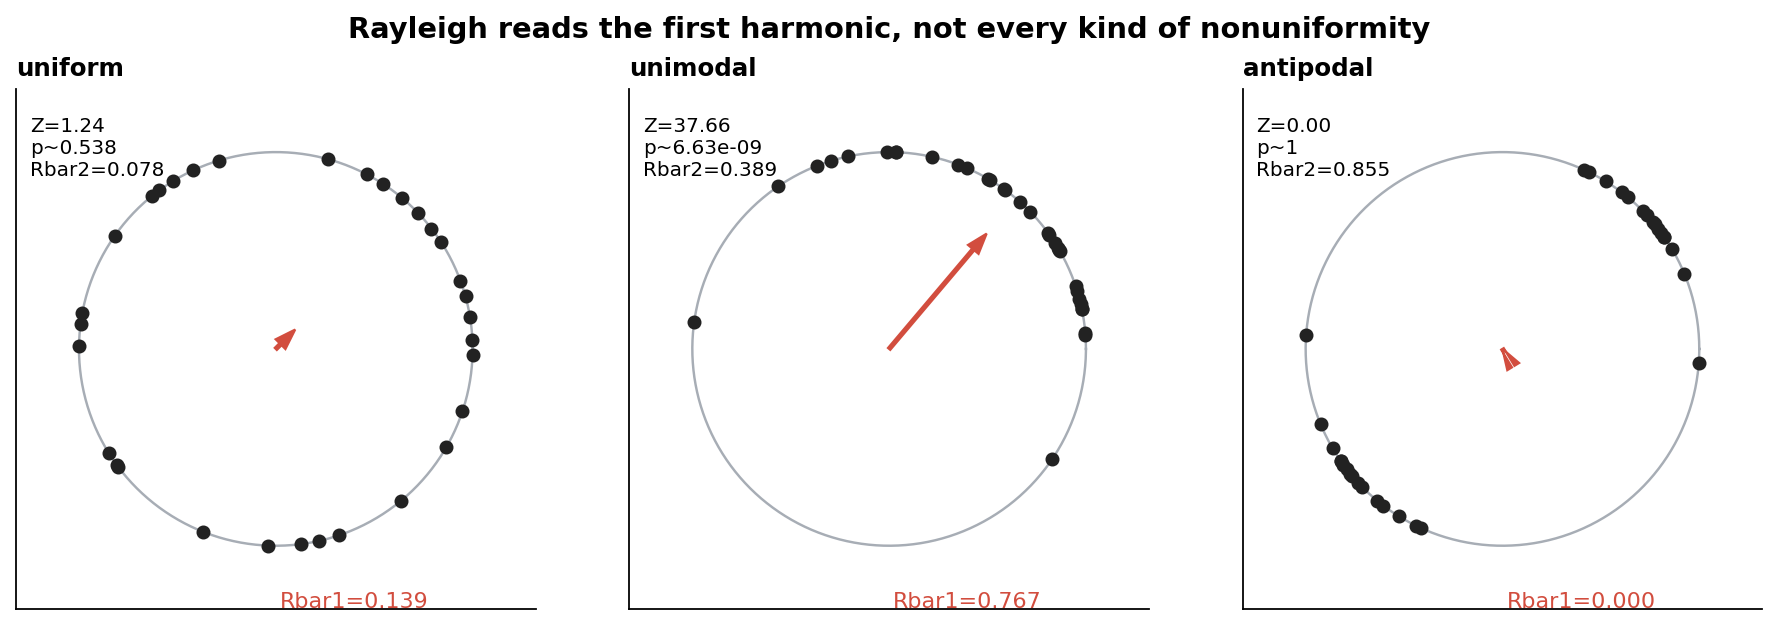

{'uniform': {'n': 32,
  'rbar': 0.13910367514367666,
  'mean_direction_radians': 0.7847827019853877,
  'statistic_2nRbar2': 1.2383892760625619,
  'chi2_df2_pvalue': 0.5383778520903465,
  'second_harmonic_rbar': 0.07784762318430526},
 'unimodal': {'n': 32,
  'rbar': 0.7671411717525439,
  'mean_direction_radians': 0.868859860687689,
  'statistic_2nRbar2': 37.66435695346343,
  'chi2_df2_pvalue': 6.6265702338246625e-09,
  'second_harmonic_rbar': 0.3888603326626704},
 'antipodal': {'n': 32,
  'rbar': 4.670885906470169e-17,
  'mean_direction_radians': 2.117585167684144,
  'statistic_2nRbar2': 1.396299209680746e-31,
  'chi2_df2_pvalue': 1.0,
  'second_harmonic_rbar': 0.8549988317253627}}

In [4]:
rayleigh_stats = {}
fig, axes = plt.subplots(1, 3, figsize=(11.5, 3.8), constrained_layout=True)
for ax, (name, theta) in zip(axes, [("uniform", uniform_sample), ("unimodal", unimodal_sample), ("antipodal", axial_sample)]):
    ray = rayleigh_test(theta)
    r2 = circular_resultant(theta, harmonic=2)[1]
    rayleigh_stats[name] = {**ray, "second_harmonic_rbar": float(r2)}
    note = f"Z={ray['statistic_2nRbar2']:.2f}\np~{ray['chi2_df2_pvalue']:.3g}\nRbar2={r2:.3f}"
    draw_unit_circle(ax, theta, name, annotate=note)
fig.suptitle("Rayleigh reads the first harmonic, not every kind of nonuniformity", fontsize=13, fontweight="bold")
rayleigh_path = save_matplotlib(fig, TOPIC, "figures", "rayleigh-first-harmonic.png")
plt.close(fig)
rayleigh_json_path = save_json(native(rayleigh_stats), TOPIC, "checks", "rayleigh-diagnostics.json")
display_artifact(rayleigh_path, width=980)
rayleigh_stats


## Kuiper and Watson: CDF Diagnostics That Survive the Origin

To draw an empirical CDF on a circle, we must cut the circle somewhere and call that cut zero. The raw one-sided deviations `D+` and `D-` depend on that cut. Kuiper's statistic `V = D+ + D-` and Watson's `U2` are designed so that rotating the cut does not change the answer.

The figure uses the same sample twice with two different origins. The step plot changes, but the combined circular statistics remain fixed. The lower panel sweeps many origins to make the invariant visible rather than merely asserted.


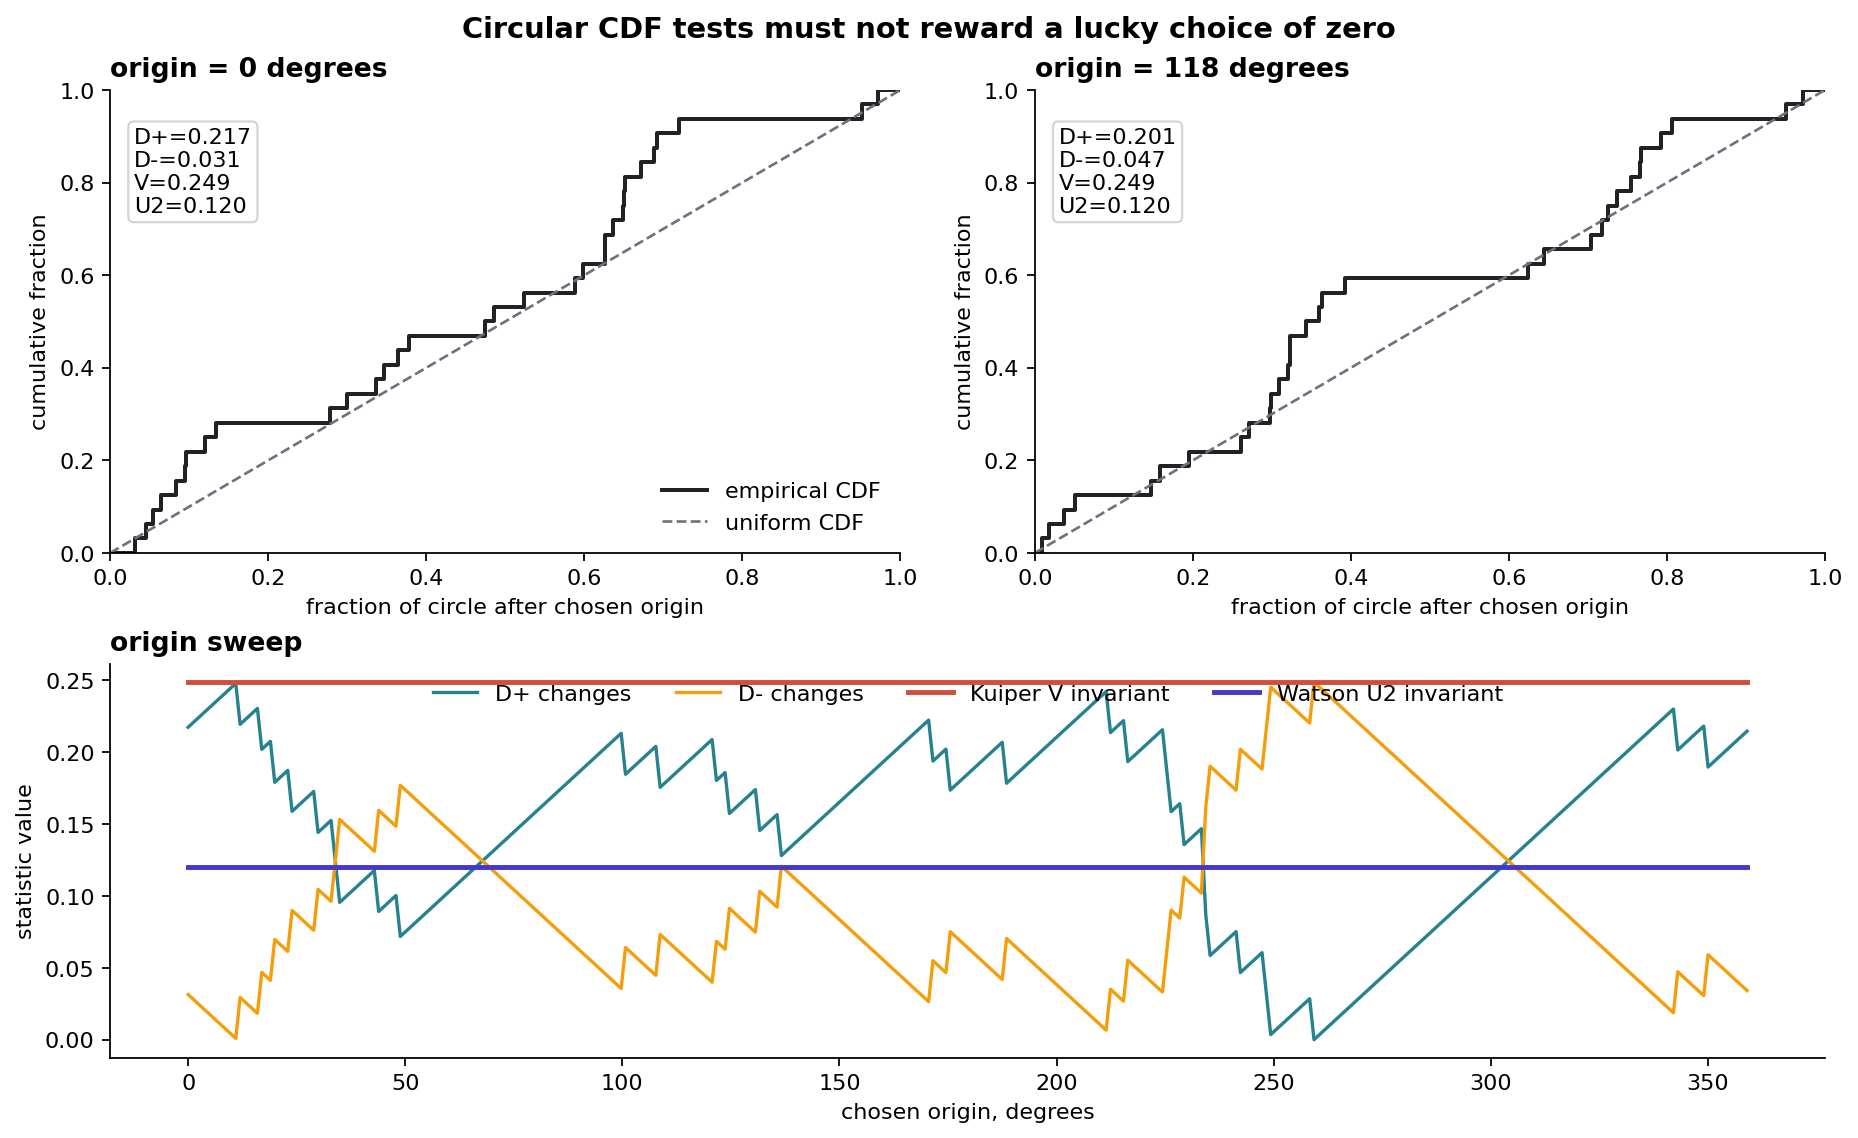

{'kuiper_V_range_across_origins': 3.3306690738754696e-16,
 'watson_U2_range_across_origins': 1.6653345369377348e-15,
 'D_plus_range_across_origins': 0.2477493074792243,
 'D_minus_range_across_origins': 0.2477493074792244,
 'raw_W2_range_across_origins': 0.7452801982288336,
 'origin_a_degrees': 0.0,
 'origin_b_degrees': 118.00000000000001}

In [5]:
origin_a = 0.0
origin_b = np.deg2rad(118)
profile_origins = np.linspace(0, TAU, 361, endpoint=False)
profile = {
    "origin_degrees": np.rad2deg(profile_origins),
    "D_plus": [],
    "D_minus": [],
    "Kuiper_V": [],
    "Watson_U2": [],
    "Watson_W2_raw": [],
}
for origin in profile_origins:
    k = kuiper_statistic(gap_cluster_sample, origin=origin)
    w = watson_u2(gap_cluster_sample, origin=origin)
    profile["D_plus"].append(k["D_plus"])
    profile["D_minus"].append(k["D_minus"])
    profile["Kuiper_V"].append(k["V"])
    profile["Watson_U2"].append(w["U2"])
    profile["Watson_W2_raw"].append(w["W2_origin_dependent"])
for key in list(profile):
    profile[key] = np.asarray(profile[key])

fig = plt.figure(figsize=(11.5, 7.0), constrained_layout=True)
gs = fig.add_gridspec(2, 2, height_ratios=[1.0, 0.85])
for col, origin in enumerate([origin_a, origin_b]):
    ax = fig.add_subplot(gs[0, col])
    u = sorted_unit(gap_cluster_sample, origin=origin)
    x, y = step_xy_from_sorted_u(u)
    k = kuiper_statistic(gap_cluster_sample, origin=origin)
    w = watson_u2(gap_cluster_sample, origin=origin)
    ax.step(x, y, where="post", color="#222222", lw=1.8, label="empirical CDF")
    ax.plot([0, 1], [0, 1], color="#6b7280", lw=1.2, ls="--", label="uniform CDF")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xlabel("fraction of circle after chosen origin")
    ax.set_ylabel("cumulative fraction")
    ax.set_title(f"origin = {np.rad2deg(origin):.0f} degrees", loc="left", fontweight="bold")
    ax.text(
        0.03,
        0.92,
        f"D+={k['D_plus']:.3f}\nD-={k['D_minus']:.3f}\nV={k['V']:.3f}\nU2={w['U2']:.3f}",
        transform=ax.transAxes,
        va="top",
        ha="left",
        bbox={"boxstyle": "round,pad=0.25", "fc": "white", "ec": "#d1d5db"},
    )
    if col == 0:
        ax.legend(loc="lower right", frameon=False)

ax = fig.add_subplot(gs[1, :])
ax.plot(profile["origin_degrees"], profile["D_plus"], color="#26828e", label="D+ changes")
ax.plot(profile["origin_degrees"], profile["D_minus"], color="#f59e0b", label="D- changes")
ax.plot(profile["origin_degrees"], profile["Kuiper_V"], color="#d24d3e", lw=2.2, label="Kuiper V invariant")
ax.plot(profile["origin_degrees"], profile["Watson_U2"], color="#4338ca", lw=2.2, label="Watson U2 invariant")
ax.set_xlabel("chosen origin, degrees")
ax.set_ylabel("statistic value")
ax.set_title("origin sweep", loc="left", fontweight="bold")
ax.legend(ncol=4, frameon=False, loc="upper center")

fig.suptitle("Circular CDF tests must not reward a lucky choice of zero", fontsize=13, fontweight="bold")
cdf_path = save_matplotlib(fig, TOPIC, "figures", "origin-invariant-cdf-diagnostics.png")
plt.close(fig)

cdf_checks = {
    "kuiper_V_range_across_origins": float(np.ptp(profile["Kuiper_V"])),
    "watson_U2_range_across_origins": float(np.ptp(profile["Watson_U2"])),
    "D_plus_range_across_origins": float(np.ptp(profile["D_plus"])),
    "D_minus_range_across_origins": float(np.ptp(profile["D_minus"])),
    "raw_W2_range_across_origins": float(np.ptp(profile["Watson_W2_raw"])),
    "origin_a_degrees": float(np.rad2deg(origin_a)),
    "origin_b_degrees": float(np.rad2deg(origin_b)),
}
cdf_json_path = save_json(native(cdf_checks), TOPIC, "checks", "cdf-rotation-invariance.json")
display_artifact(cdf_path, width=980)
cdf_checks


In [6]:
interactive_fig = make_subplots(
    rows=2,
    cols=1,
    shared_xaxes=True,
    subplot_titles=("One-sided CDF discrepancies move with the origin", "Circular combinations stay fixed"),
)
interactive_fig.add_trace(go.Scatter(x=profile["origin_degrees"], y=profile["D_plus"], name="D+", mode="lines", line={"color": "#26828e"}), row=1, col=1)
interactive_fig.add_trace(go.Scatter(x=profile["origin_degrees"], y=profile["D_minus"], name="D-", mode="lines", line={"color": "#f59e0b"}), row=1, col=1)
interactive_fig.add_trace(go.Scatter(x=profile["origin_degrees"], y=profile["Kuiper_V"], name="Kuiper V", mode="lines", line={"color": "#d24d3e", "width": 3}), row=2, col=1)
interactive_fig.add_trace(go.Scatter(x=profile["origin_degrees"], y=profile["Watson_U2"], name="Watson U2", mode="lines", line={"color": "#4338ca", "width": 3}), row=2, col=1)
interactive_fig.update_xaxes(title_text="origin, degrees", row=2, col=1)
interactive_fig.update_yaxes(title_text="value", row=1, col=1)
interactive_fig.update_yaxes(title_text="value", row=2, col=1)
interactive_fig.update_layout(
    title="Origin-shift diagnostic for Kuiper and Watson statistics",
    height=650,
    template="plotly_white",
    hovermode="x unified",
    legend={"orientation": "h", "y": -0.12},
)
origin_html_path = save_plotly_html(interactive_fig, TOPIC, "interactive", "origin-shift-diagnostics.html", include_plotlyjs=True)
display_artifact(origin_html_path, width="100%", height=520)


## Spacings and Semicircle Scans

CDF tests compare a step function with the uniform diagonal. Spacing tests ask a different geometric question: do adjacent ordered angles leave suspiciously large or small arcs? Semicircle scans ask whether some half-circle captures far too many observations, or whether some half-circle is nearly empty.

The sample below is intentionally clustered. The largest gap is visible on the circle, the gap bar plot shows which arc creates the small covering range, and the semicircle scan tracks the count inside a moving half-circle.


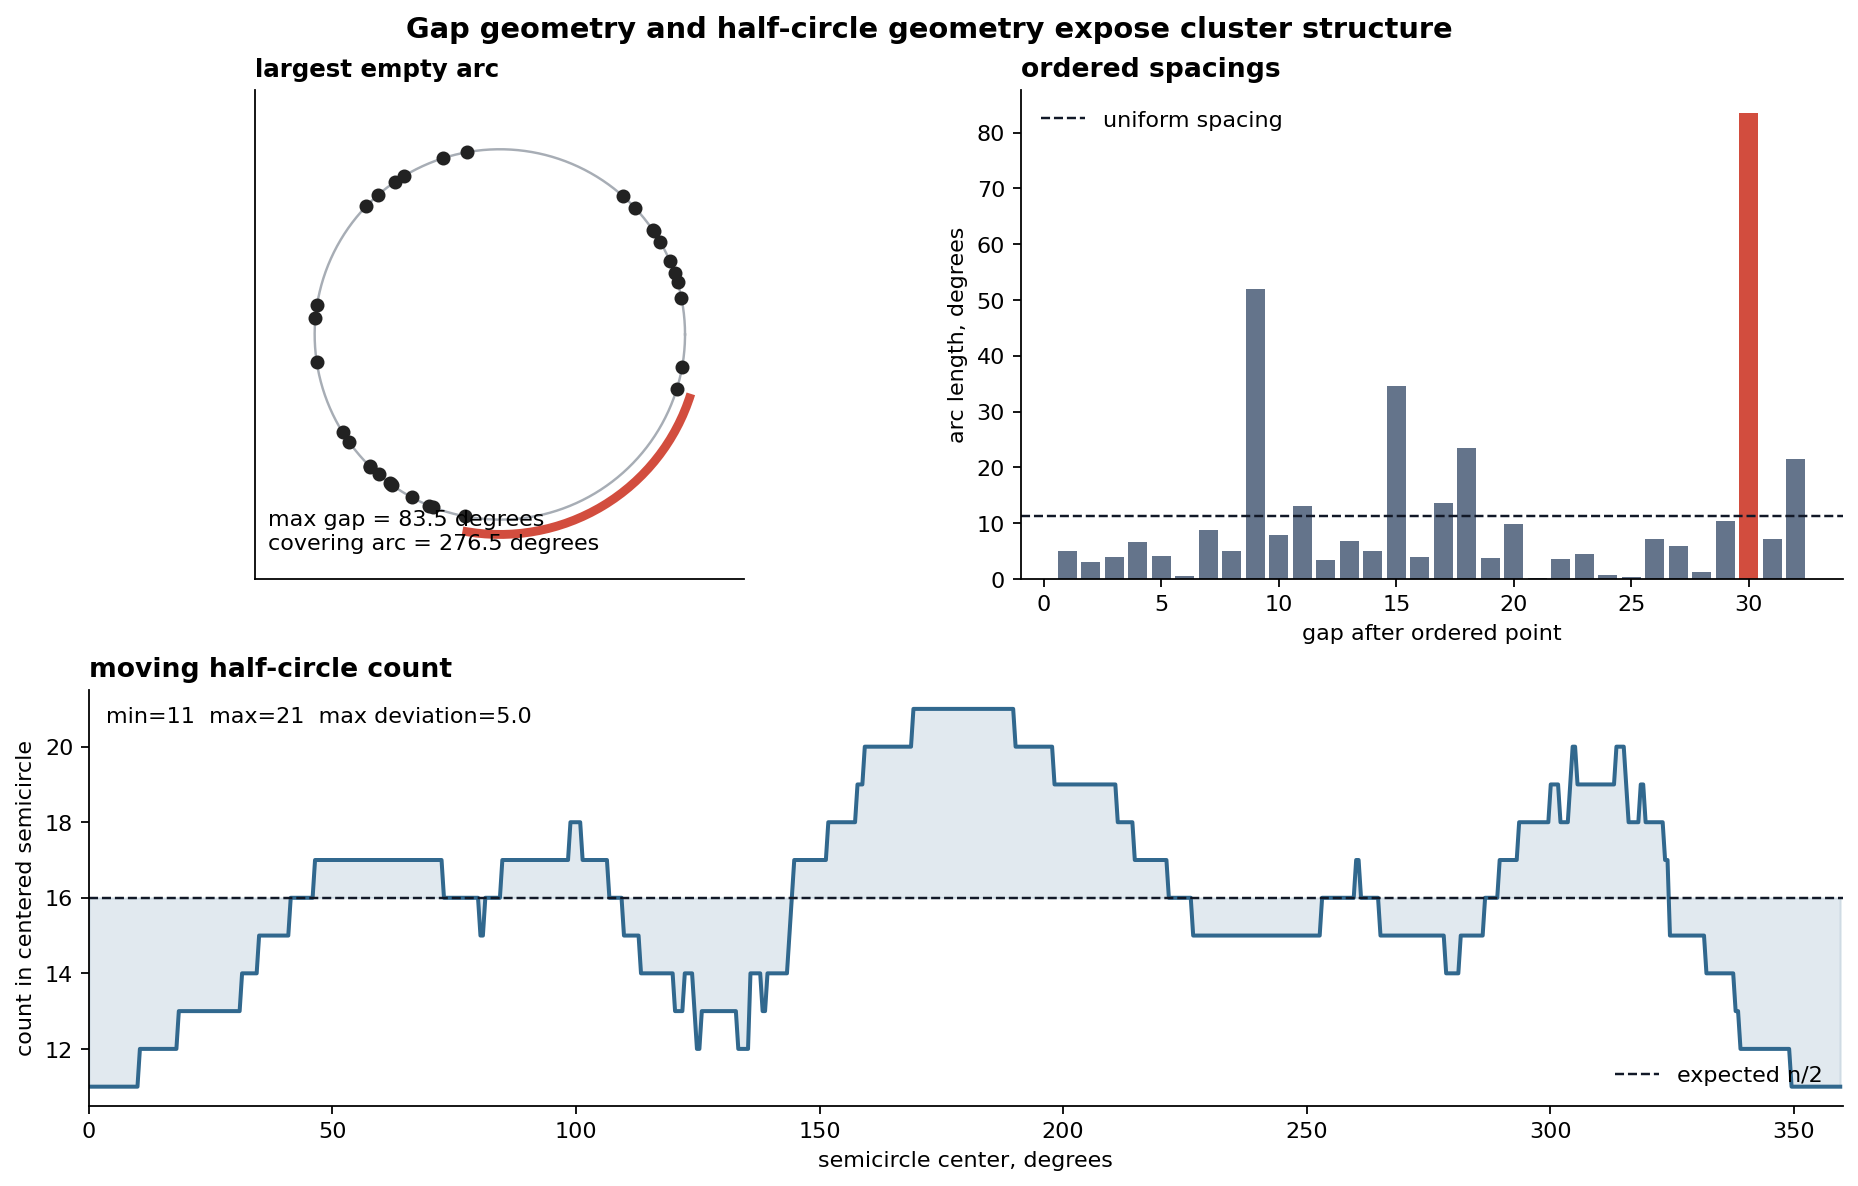

{'max_gap_degrees': 83.47827973368733,
 'min_gap_degrees': 0.19282005267086788,
 'smallest_covering_arc_degrees': 276.5217202663127,
 'rao_spacing_L_degrees': 162.82488057164466,
 'semicircle_min_count': 11,
 'semicircle_max_count': 21,
 'semicircle_max_abs_deviation_from_half': 5.0}

In [7]:
spacing = spacing_statistics(gap_cluster_sample)
semi = semicircle_scan(gap_cluster_sample)
u = sorted_unit(gap_cluster_sample)
gaps = spacing["gaps_cycles"]
largest_gap_index = int(np.argmax(gaps))
start = u[largest_gap_index]
arc_start = start * 360
arc_extent = gaps[largest_gap_index] * 360

fig = plt.figure(figsize=(11.5, 7.3), constrained_layout=True)
gs = fig.add_gridspec(2, 2, height_ratios=[1.0, 0.85])
ax_circle = fig.add_subplot(gs[0, 0])
draw_unit_circle(ax_circle, gap_cluster_sample, "largest empty arc", mean_arrow=False)
arc = Arc((0, 0), 2.16, 2.16, theta1=arc_start, theta2=arc_start + arc_extent, color="#d24d3e", lw=4)
ax_circle.add_patch(arc)
ax_circle.text(
    -1.25,
    -1.18,
    f"max gap = {spacing['max_gap_cycles'] * 360:.1f} degrees\ncovering arc = {spacing['smallest_covering_arc_cycles'] * 360:.1f} degrees",
    ha="left",
    va="bottom",
)

ax_gap = fig.add_subplot(gs[0, 1])
ax_gap.bar(np.arange(1, len(gaps) + 1), gaps * 360, color=["#d24d3e" if i == largest_gap_index else "#64748b" for i in range(len(gaps))])
ax_gap.axhline(360 / len(gaps), color="#111827", ls="--", lw=1.1, label="uniform spacing")
ax_gap.set_xlabel("gap after ordered point")
ax_gap.set_ylabel("arc length, degrees")
ax_gap.set_title("ordered spacings", loc="left", fontweight="bold")
ax_gap.legend(frameon=False)

ax_scan = fig.add_subplot(gs[1, :])
centers_deg = np.rad2deg(semi["centers"])
ax_scan.plot(centers_deg, semi["counts"], color="#31688e", lw=1.8)
ax_scan.axhline(len(gap_cluster_sample) / 2, color="#111827", ls="--", lw=1.1, label="expected n/2")
ax_scan.fill_between(centers_deg, len(gap_cluster_sample) / 2, semi["counts"], color="#31688e", alpha=0.14)
ax_scan.set_xlim(0, 360)
ax_scan.set_xlabel("semicircle center, degrees")
ax_scan.set_ylabel("count in centered semicircle")
ax_scan.set_title("moving half-circle count", loc="left", fontweight="bold")
ax_scan.text(
    0.01,
    0.96,
    f"min={semi['min_count']}  max={semi['max_count']}  max deviation={semi['max_abs_deviation_from_half']:.1f}",
    transform=ax_scan.transAxes,
    va="top",
    ha="left",
)
ax_scan.legend(frameon=False, loc="lower right")

fig.suptitle("Gap geometry and half-circle geometry expose cluster structure", fontsize=13, fontweight="bold")
spacing_path = save_matplotlib(fig, TOPIC, "figures", "spacing-semicircle-scan.png")
plt.close(fig)

spacing_summary = {
    "max_gap_degrees": float(spacing["max_gap_cycles"] * 360),
    "min_gap_degrees": float(spacing["min_gap_cycles"] * 360),
    "smallest_covering_arc_degrees": float(spacing["smallest_covering_arc_cycles"] * 360),
    "rao_spacing_L_degrees": float(spacing["rao_spacing_L_degrees"]),
    "semicircle_min_count": semi["min_count"],
    "semicircle_max_count": semi["max_count"],
    "semicircle_max_abs_deviation_from_half": semi["max_abs_deviation_from_half"],
}
spacing_json_path = save_json(native(spacing_summary), TOPIC, "checks", "spacing-semicircle-summary.json")
display_artifact(spacing_path, width=980)
spacing_summary


## Goodness-of-Fit via the Circular Probability Integral Transform

For a continuous circular model with CDF `F`, the transform `theta -> 2*pi*F(theta)` should produce uniform circular angles when the model is correct. That converts goodness-of-fit into a uniformity problem.

The example fits a von Mises model by moment estimates, then compares two transforms: the fitted von Mises PIT and the uniform-model PIT. The uniform-model transform is just the original angle scale, so it remains clustered. The fitted transform spreads the sample more evenly. Because parameters are estimated, the null distribution for the fitted-model test is not exactly the same as the pure uniformity null; the statistic still gives a useful diagnostic and motivates the specialized tables discussed in the source chapter.


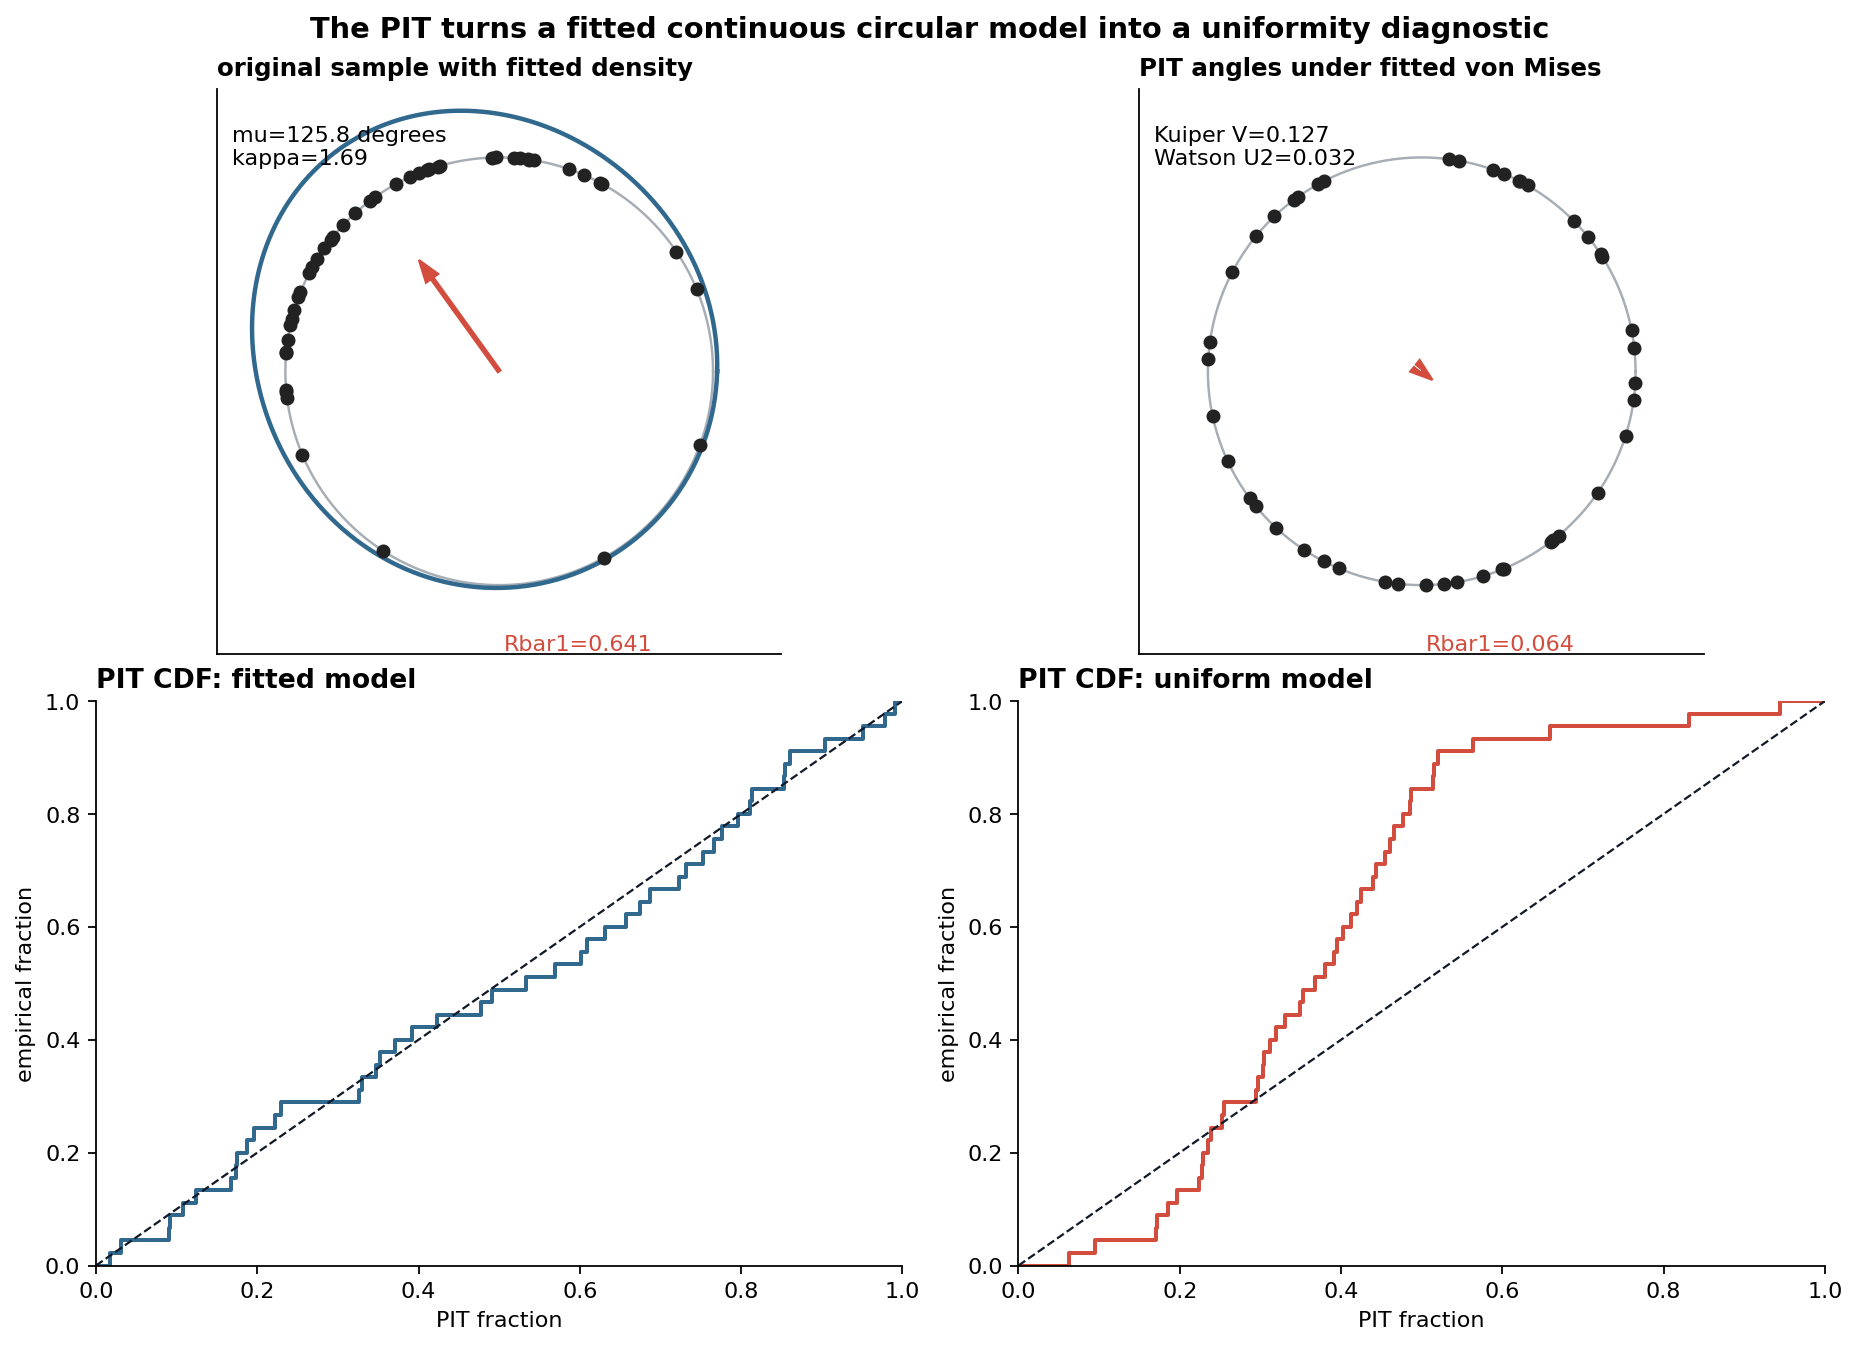

{'fit': {'mu': 2.195943002470198,
  'rbar': 0.641128483335997,
  'kappa': 1.6893690062839473},
 'fitted_model_pit_stats': {'rayleigh_Z': 0.3705048617543271,
  'rayleigh_p_chi2': 0.8308945139460531,
  'rbar1': 0.06416167614829892,
  'rbar2': 0.12914152520313404,
  'kuiper_V': 0.1272758704796503,
  'kuiper_V_star': 0.8780738147608238,
  'watson_U2': 0.03171325069870138,
  'watson_U2_star': 0.030065574058173488,
  'rao_L_degrees': 112.8850651541105,
  'max_gap_degrees': 34.621467690025625,
  'semicircle_min_count': 18,
  'semicircle_max_count': 27},
 'uniform_model_pit_stats': {'rayleigh_Z': 36.99411589302443,
  'rayleigh_p_chi2': 9.264666750399948e-09,
  'rbar1': 0.641128483335997,
  'rbar2': 0.24401803754096935,
  'kuiper_V': 0.5170515687138867,
  'kuiper_V_star': 3.5671289589903896,
  'watson_U2': 0.9831125351419404,
  'watson_U2_star': 0.9983786235581811,
  'rao_L_degrees': 188.1837897920783,
  'max_gap_degrees': 62.12591022097999,
  'semicircle_min_count': 4,
  'semicircle_max_count'

In [8]:
fit = fit_von_mises_moments(gof_sample)
pit_fitted = pit_angles_von_mises(gof_sample, fit["kappa"], fit["mu"])
pit_uniform_model = wrap(gof_sample)

pit_fitted_stats = all_uniformity_stats(pit_fitted)
pit_uniform_stats = all_uniformity_stats(pit_uniform_model)

plot_grid = np.linspace(0, TAU, 500)
density = vonmises.pdf(plot_grid, fit["kappa"], loc=fit["mu"])

fig, axes = plt.subplots(2, 2, figsize=(11.5, 8.3), constrained_layout=True)
draw_unit_circle(axes[0, 0], gof_sample, "original sample with fitted density", density=density, mean_arrow=True)
axes[0, 0].text(-1.25, 1.15, f"mu={np.rad2deg(fit['mu']):.1f} degrees\nkappa={fit['kappa']:.2f}", ha="left", va="top")
draw_unit_circle(axes[0, 1], pit_fitted, "PIT angles under fitted von Mises", mean_arrow=True)
axes[0, 1].text(-1.25, 1.15, f"Kuiper V={pit_fitted_stats['kuiper_V']:.3f}\nWatson U2={pit_fitted_stats['watson_U2']:.3f}", ha="left", va="top")

for ax, theta, title, color in [
    (axes[1, 0], pit_fitted, "PIT CDF: fitted model", "#31688e"),
    (axes[1, 1], pit_uniform_model, "PIT CDF: uniform model", "#d24d3e"),
]:
    u = sorted_unit(theta)
    x, y = step_xy_from_sorted_u(u)
    ax.step(x, y, where="post", color=color, lw=1.8)
    ax.plot([0, 1], [0, 1], color="#111827", ls="--", lw=1.0)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xlabel("PIT fraction")
    ax.set_ylabel("empirical fraction")
    ax.set_title(title, loc="left", fontweight="bold")

fig.suptitle("The PIT turns a fitted continuous circular model into a uniformity diagnostic", fontsize=13, fontweight="bold")
pit_path = save_matplotlib(fig, TOPIC, "figures", "pit-goodness-of-fit.png")
plt.close(fig)

pit_summary = {
    "fit": fit,
    "fitted_model_pit_stats": pit_fitted_stats,
    "uniform_model_pit_stats": pit_uniform_stats,
    "pit_fitted_min": float(np.min(pit_fitted / TAU)),
    "pit_fitted_max": float(np.max(pit_fitted / TAU)),
    "fitted_improves_kuiper_over_uniform_model": bool(pit_fitted_stats["kuiper_V"] < pit_uniform_stats["kuiper_V"]),
    "fitted_improves_watson_over_uniform_model": bool(pit_fitted_stats["watson_U2"] < pit_uniform_stats["watson_U2"]),
}
pit_json_path = save_json(native(pit_summary), TOPIC, "checks", "pit-goodness-of-fit.json")
display_artifact(pit_path, width=980)
pit_summary


## Simulation Check: Calibration and Failure Modes

The source chapter gives analytic approximations and tables for several statistics. Here, simulation plays a narrower role: it checks the direction of the diagnostics and makes failure modes visible. The null samples are uniform on the circle; the observed markers are the synthetic alternatives from the earlier panels.


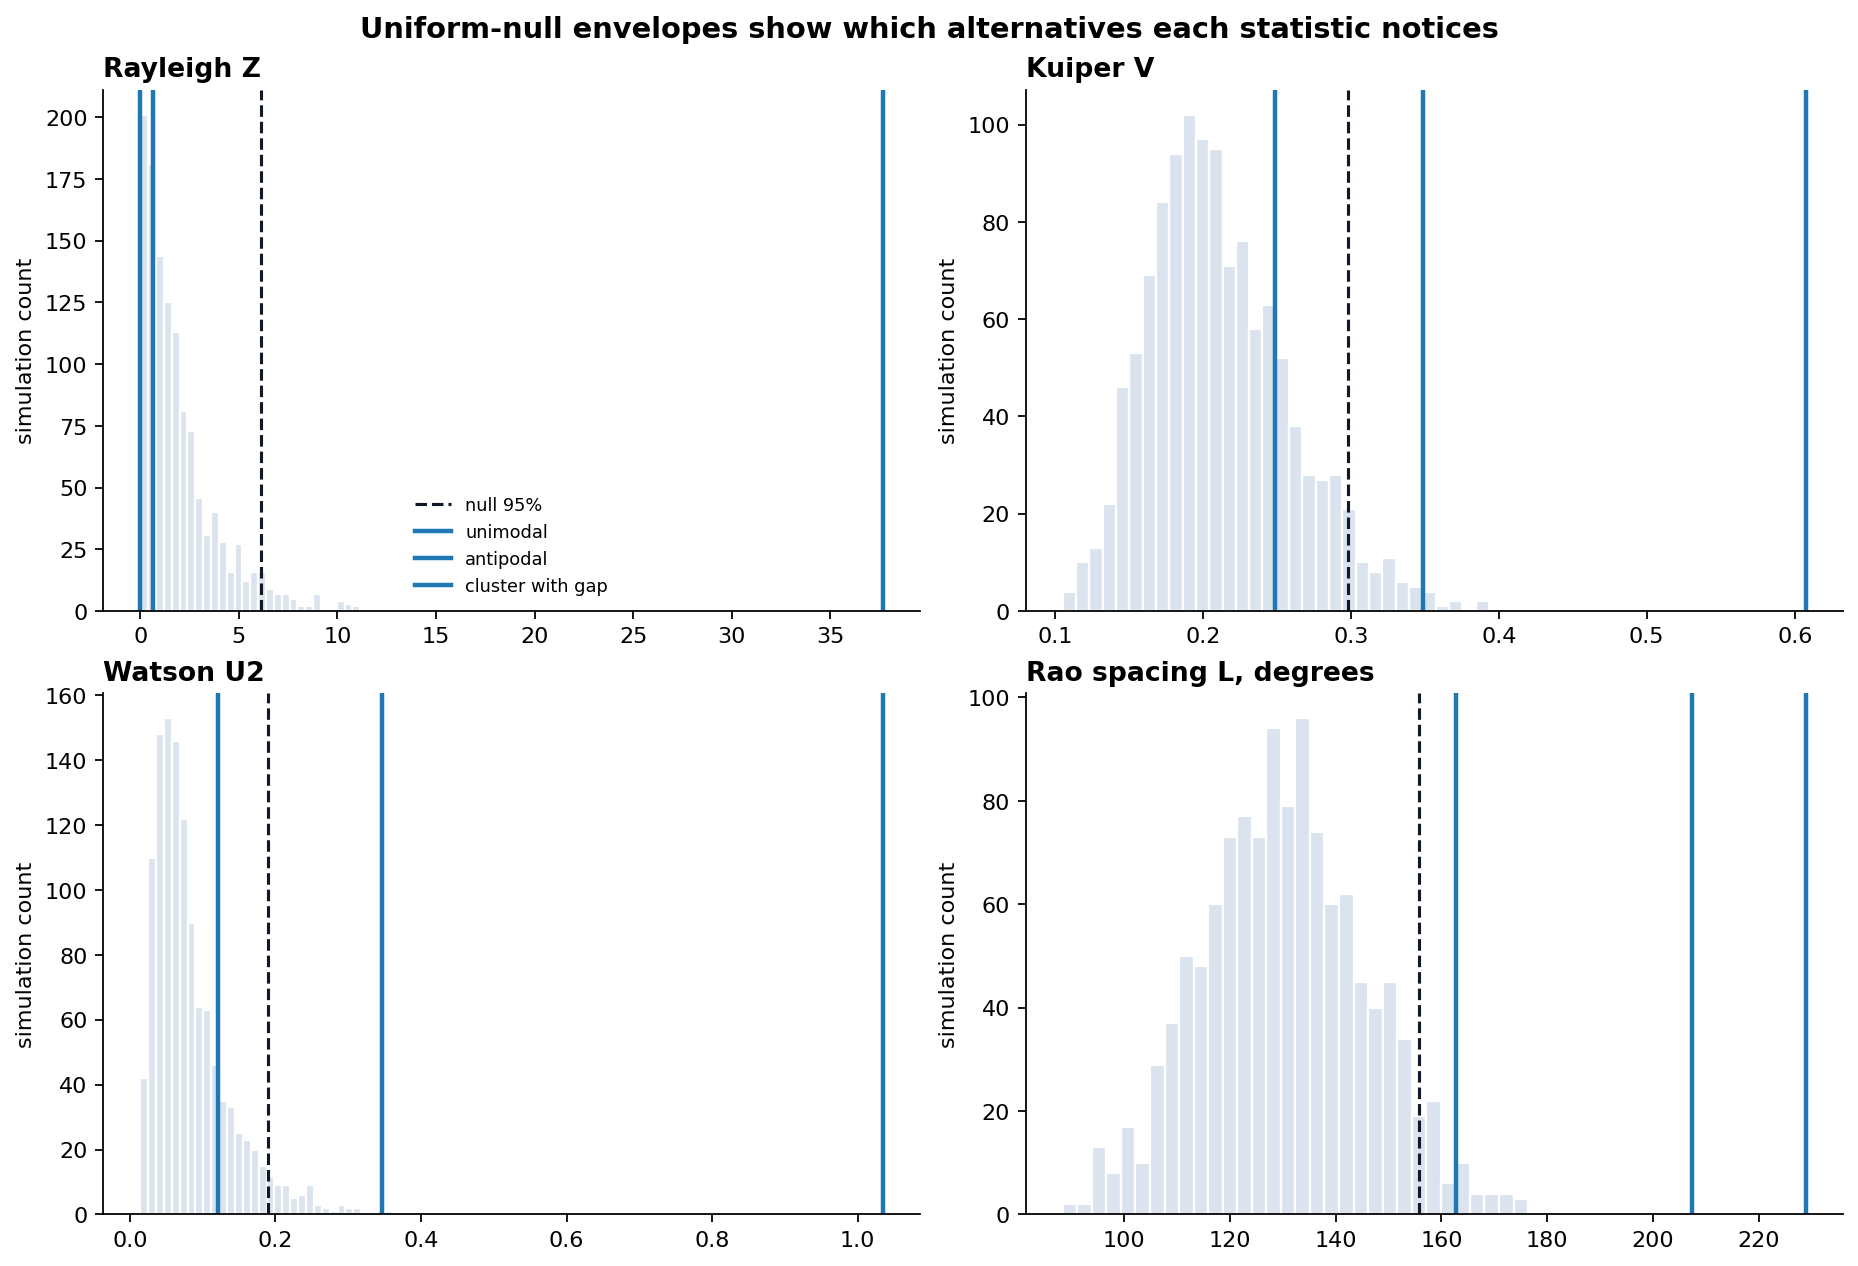

{'unimodal': {'rayleigh_Z': 0.0008326394671107411,
  'kuiper_V': 0.0008326394671107411,
  'watson_U2': 0.0008326394671107411,
  'rao_L_degrees': 0.0008326394671107411},
 'antipodal': {'rayleigh_Z': 1.0,
  'kuiper_V': 0.00832639467110741,
  'watson_U2': 0.002497918401332223,
  'rao_L_degrees': 0.0008326394671107411},
 'cluster with gap': {'rayleigh_Z': 0.7310574521232306,
  'kuiper_V': 0.2048293089092423,
  'watson_U2': 0.18484596169858453,
  'rao_L_degrees': 0.020815986677768527}}

In [9]:
null_stats = simulate_uniform_stats(n=n, reps=1200, seed=606)
observed_stats = {name: all_uniformity_stats(theta) for name, theta in samples.items() if name != "synthetic uniform"}

stat_specs = [
    ("rayleigh_Z", "Rayleigh Z", "#d24d3e"),
    ("kuiper_V", "Kuiper V", "#26828e"),
    ("watson_U2", "Watson U2", "#4338ca"),
    ("rao_L_degrees", "Rao spacing L, degrees", "#f59e0b"),
]

fig, axes = plt.subplots(2, 2, figsize=(11.5, 7.8), constrained_layout=True)
for ax, (key, label, color) in zip(axes.ravel(), stat_specs):
    ax.hist(null_stats[key], bins=32, color="#dbe4ee", edgecolor="white")
    q95 = np.quantile(null_stats[key], 0.95)
    ax.axvline(q95, color="#111827", lw=1.4, ls="--", label="null 95%")
    for name, stats in observed_stats.items():
        ax.axvline(stats[key], lw=2.0, label=name)
    ax.set_title(label, loc="left", fontweight="bold")
    ax.set_ylabel("simulation count")
axes[0, 0].legend(frameon=False, fontsize=8)
fig.suptitle("Uniform-null envelopes show which alternatives each statistic notices", fontsize=13, fontweight="bold")
simulation_path = save_matplotlib(fig, TOPIC, "figures", "simulation-null-envelopes.png")
plt.close(fig)

simulation_summary = {
    "n": n,
    "reps": int(next(iter(null_stats.values())).size),
    "null_quantiles_95": {key: float(np.quantile(values, 0.95)) for key, values in null_stats.items()},
    "observed": native(observed_stats),
    "empirical_upper_tail_pvalues": {
        name: {key: empirical_pvalue(null_stats[key], stats[key]) for key in null_stats}
        for name, stats in observed_stats.items()
    },
}
simulation_json_path = save_json(native(simulation_summary), TOPIC, "checks", "simulation-summary.json")
display_artifact(simulation_path, width=980)
simulation_summary["empirical_upper_tail_pvalues"]


## Applied Lab: Build an Origin-Invariant Test Report for a New Circular Sample

A useful circular test report should state the geometry it is trying to detect. The lab sample below has one broad mode and one narrow secondary mode. The code computes a compact report, rotates the origin through many cuts, and records which statistics are invariant.


In [10]:
lab_sample = wrap(np.r_[
    rng.vonmises(mu=np.deg2rad(310), kappa=3.0, size=24),
    rng.vonmises(mu=np.deg2rad(90), kappa=12.0, size=8),
])
lab_origins = rng.uniform(0, TAU, size=80)
lab_kuiper = np.array([kuiper_statistic(lab_sample, origin=o)["V"] for o in lab_origins])
lab_watson = np.array([watson_u2(lab_sample, origin=o)["U2"] for o in lab_origins])
lab_dplus = np.array([kuiper_statistic(lab_sample, origin=o)["D_plus"] for o in lab_origins])
lab_stats = all_uniformity_stats(lab_sample)
lab_null = simulate_uniform_stats(n=len(lab_sample), reps=900, seed=909)
lab_report = {
    "sample_size": len(lab_sample),
    "stats": lab_stats,
    "empirical_upper_tail_pvalues": {key: empirical_pvalue(lab_null[key], lab_stats[key]) for key in lab_null},
    "origin_invariance": {
        "kuiper_V_range": float(np.ptp(lab_kuiper)),
        "watson_U2_range": float(np.ptp(lab_watson)),
        "D_plus_range": float(np.ptp(lab_dplus)),
    },
    "interpretation_prompt": "Compare Rayleigh, omnibus CDF, and spacing p-values before naming the alternative geometry.",
}
lab_json_path = save_json(native(lab_report), TOPIC, "checks", "applied-lab-report.json")
lab_report


{'sample_size': 32,
 'stats': {'rayleigh_Z': 9.763936177859879,
  'rayleigh_p_chi2': 0.0075820771317603,
  'rbar1': 0.39059122209678576,
  'rbar2': 0.4507980325051493,
  'kuiper_V': 0.3858540871030319,
  'kuiper_V_star': 2.2588981183061048,
  'watson_U2': 0.35962745811430946,
  'watson_U2_star': 0.3655151172234172,
  'rao_L_degrees': 182.32900342421425,
  'max_gap_degrees': 120.7912492796597,
  'semicircle_min_count': 8,
  'semicircle_max_count': 24},
 'empirical_upper_tail_pvalues': {'rayleigh_Z': 0.004439511653718091,
  'kuiper_V': 0.0011098779134295228,
  'watson_U2': 0.0011098779134295228,
  'rao_L_degrees': 0.0011098779134295228},
 'origin_invariance': {'kuiper_V_range': 2.220446049250313e-16,
  'watson_U2_range': 1.4988010832439613e-15,
  'D_plus_range': 0.37619369427579485},
 'interpretation_prompt': 'Compare Rayleigh, omnibus CDF, and spacing p-values before naming the alternative geometry.'}

## Sanity Checks

These checks make the notebook auditable. They verify artifact existence, core identities, rotation invariance, PIT range, and simulation behavior. They also confirm that the generic topic-visual helper removed by this pass is not referenced by the canonical notebook.


In [11]:
artifact_paths = [
    rayleigh_path,
    cdf_path,
    origin_html_path,
    spacing_path,
    pit_path,
    simulation_path,
    rayleigh_json_path,
    cdf_json_path,
    spacing_json_path,
    pit_json_path,
    simulation_json_path,
    lab_json_path,
]
artifact_checks = assert_artifacts(artifact_paths, min_bytes=100)

ray = rayleigh_test(unimodal_sample)
ray_identity_left = ray["statistic_2nRbar2"]
ray_identity_right = 2 * len(unimodal_sample) * ray["rbar"] ** 2
assert abs(ray_identity_left - ray_identity_right) < 1e-12

rotation = np.deg2rad(73)
rotated_rayleigh = rayleigh_test(wrap(unimodal_sample + rotation))["statistic_2nRbar2"]
assert abs(rotated_rayleigh - ray["statistic_2nRbar2"]) < 1e-12
assert cdf_checks["kuiper_V_range_across_origins"] < 1e-12
assert cdf_checks["watson_U2_range_across_origins"] < 1e-12
assert cdf_checks["D_plus_range_across_origins"] > 0.02
assert spacing_summary["max_gap_degrees"] > 360 / len(gap_cluster_sample)
assert 0.0 <= pit_summary["pit_fitted_min"] <= pit_summary["pit_fitted_max"] <= 1.0
assert pit_summary["fitted_improves_kuiper_over_uniform_model"]
assert pit_summary["fitted_improves_watson_over_uniform_model"]
assert rayleigh_stats["antipodal"]["second_harmonic_rbar"] > 0.85
assert rayleigh_stats["antipodal"]["rbar"] < 1e-12
assert simulation_summary["empirical_upper_tail_pvalues"]["unimodal"]["rayleigh_Z"] < 0.05
assert simulation_summary["empirical_upper_tail_pvalues"]["antipodal"]["kuiper_V"] < 0.05
assert simulation_summary["empirical_upper_tail_pvalues"]["cluster with gap"]["rao_L_degrees"] < 0.05

notebook_text = (
    BOOK_ROOT
    / "part-01-circular-statistics"
    / "chapter-06-tests-of-uniformity-and-goodness-of-fit"
    / "06-tests-of-uniformity-and-goodness-of-fit.ipynb"
).read_text(encoding="utf-8")
forbidden_helper = "make_topic" + "_static_figure"
forbidden_module = "utils" + ".topic_visuals"
assert forbidden_helper not in notebook_text
assert forbidden_module not in notebook_text

numeric_checks = {
    "rayleigh_identity_abs_error": abs(ray_identity_left - ray_identity_right),
    "rayleigh_rotation_abs_error": abs(rotated_rayleigh - ray["statistic_2nRbar2"]),
    "kuiper_V_rotation_range": cdf_checks["kuiper_V_range_across_origins"],
    "watson_U2_rotation_range": cdf_checks["watson_U2_range_across_origins"],
    "pit_fitted_kuiper": pit_summary["fitted_model_pit_stats"]["kuiper_V"],
    "pit_uniform_model_kuiper": pit_summary["uniform_model_pit_stats"]["kuiper_V"],
    "lab_kuiper_V_range": lab_report["origin_invariance"]["kuiper_V_range"],
    "lab_watson_U2_range": lab_report["origin_invariance"]["watson_U2_range"],
}
numeric_checks_path = save_json(native(numeric_checks), TOPIC, "checks", "numeric-checks.json")

final_sanity = {
    "source_span": "printed pp. 93-118; PDF pp. 110-135",
    "artifacts": artifact_checks + [artifact_record(numeric_checks_path)],
    "core_numeric_checks": numeric_checks,
    "generic_topic_static_helper_removed": True,
    "chapter_specific_coverage": [
        "Rayleigh first harmonic test",
        "Kuiper and Watson origin-invariant CDF diagnostics",
        "spacing and semicircle scans",
        "PIT goodness-of-fit for a continuous circular model",
        "simulation calibration and rotation invariance checks",
    ],
}
final_sanity_path = save_json(native(final_sanity), TOPIC, "checks", "final-sanity.json")
final_sanity


{'source_span': 'printed pp. 93-118; PDF pp. 110-135',
 'artifacts': [{'path': 'artifacts/chapter-06/figures/rayleigh-first-harmonic.png',
   'exists': True,
   'bytes': 86891},
  {'path': 'artifacts/chapter-06/figures/origin-invariant-cdf-diagnostics.png',
   'exists': True,
   'bytes': 197768},
  {'path': 'artifacts/chapter-06/interactive/origin-shift-diagnostics.html',
   'exists': True,
   'bytes': 4891240},
  {'path': 'artifacts/chapter-06/figures/spacing-semicircle-scan.png',
   'exists': True,
   'bytes': 140291},
  {'path': 'artifacts/chapter-06/figures/pit-goodness-of-fit.png',
   'exists': True,
   'bytes': 160479},
  {'path': 'artifacts/chapter-06/figures/simulation-null-envelopes.png',
   'exists': True,
   'bytes': 96863},
  {'path': 'artifacts/chapter-06/checks/rayleigh-diagnostics.json',
   'exists': True,
   'bytes': 774},
  {'path': 'artifacts/chapter-06/checks/cdf-rotation-invariance.json',
   'exists': True,
   'bytes': 358},
  {'path': 'artifacts/chapter-06/checks/s

## Takeaways

- Rayleigh's test is a first-harmonic detector. It is geometrically natural for one preferred direction and geometrically blind to perfectly antipodal cancellation.
- Kuiper and Watson start from empirical CDF discrepancies, but their circular forms remove dependence on the arbitrary zero angle.
- Spacing and semicircle scans are useful when nonuniformity is a gap, a cluster, or an overloaded half-circle rather than a single mean direction.
- PIT goodness-of-fit is a bridge: fit or specify a continuous circular model, transform by its CDF, then use circular uniformity diagnostics on the transformed angles.
- Rotation invariance is not a cosmetic property in this chapter. It is the contract that makes a statistic well-defined on the circle rather than on a chosen coordinate cut.
